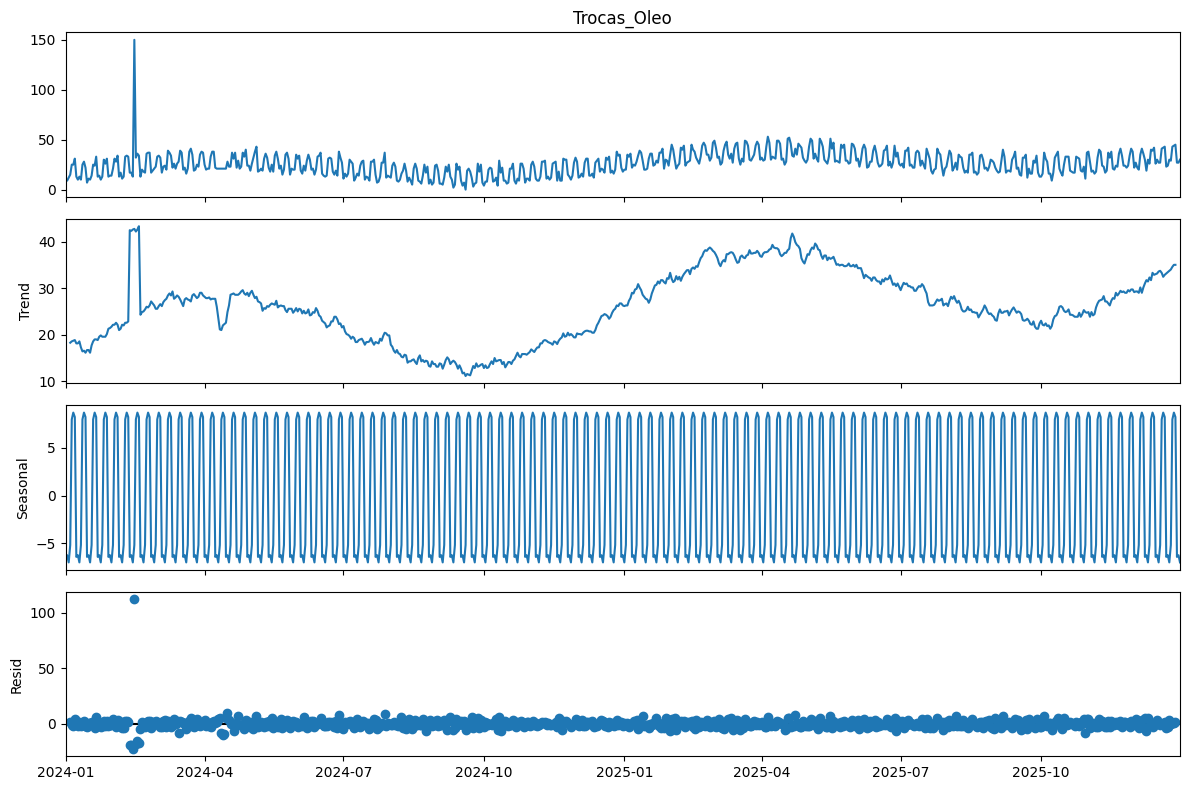

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose


df = pd.read_csv('/content/mecaniqa_dataset.csv')


df['Data'] = pd.to_datetime(df['Data'])
df = df.set_index('Data').sort_index()


df['Trocas_Oleo'] = df['Trocas_Oleo'].ffill()


decomposicao = seasonal_decompose(df['Trocas_Oleo'], model='additive', period=7)


fig = decomposicao.plot()
fig.set_size_inches(12, 8)
plt.tight_layout()
plt.show()

In [8]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor


df_pipeline = df.copy()


df_pipeline['target_trocas_oleo'] = df_pipeline['Trocas_Oleo'].shift(-1)


df_pipeline.dropna(subset=['target_trocas_oleo'], inplace=True)


df_pipeline['dia_da_semana'] = df_pipeline.index.dayofweek
df_pipeline['mes'] = df_pipeline.index.month
df_pipeline['dia_do_ano'] = df_pipeline.index.dayofyear


X_train = df_pipeline[['Trocas_Oleo', 'Manutencao_Motor', 'dia_da_semana', 'mes', 'dia_do_ano']]
y_train = df_pipeline['target_trocas_oleo']

print("Dados X_train e y_train preparados com sucesso!")
print(f"Formato de X_train: {X_train.shape}")
print(f"Formato de y_train: {y_train.shape}")

Dados X_train e y_train preparados com sucesso!
Formato de X_train: (730, 5)
Formato de y_train: (730,)


In [9]:
pipeline_steps = [
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler()),
    ('regressor', RandomForestRegressor(random_state=42, n_estimators=100))
]

mecaniqa_pipeline = Pipeline(pipeline_steps)

mecaniqa_pipeline.fit(X_train, y_train)

print("\nPipeline da MecâniQA treinado com sucesso!")
print("Componentes do Pipeline:")
display(mecaniqa_pipeline)



Pipeline da MecâniQA treinado com sucesso!
Componentes do Pipeline:


Pipeline(steps=[('imputer', SimpleImputer()), ('scaler', StandardScaler()),
                ('regressor', RandomForestRegressor(random_state=42))])